# Detecção e Reconstrução de Malha Viária a partir de Imagens de Satélite

**Disciplina:** Reconhecimento de Padrões  
**Integrantes:** Beatriz Vocurca Frade, Johnatan Augusto Moreira do Carmo e Marina Alves Resende

Este notebook implementa um pipeline de visão computacional clássica para detectar vias, gerar máscaras segmentadas, sobrepor o resultado na imagem original e extrair um grafo da malha viária.

## 0. Setup

In [ ]:
from pathlib import Path

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebook":
    PROJECT_ROOT = PROJECT_ROOT.parent

RAW_DIR     = PROJECT_ROOT / "data" / "raw"
RESULTS_DIR = PROJECT_ROOT / "data" / "results"
GRAPHS_DIR  = PROJECT_ROOT / "data" / "graphs"

RAW_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
GRAPHS_DIR.mkdir(parents=True, exist_ok=True)

print(f"Raiz: {PROJECT_ROOT}")


Raiz: /content


## 1. Pipeline de detecção

Raiz: /content
Processando: rural.png
Processando: urbana.png
Processando: akRJb7ts4w.jpg


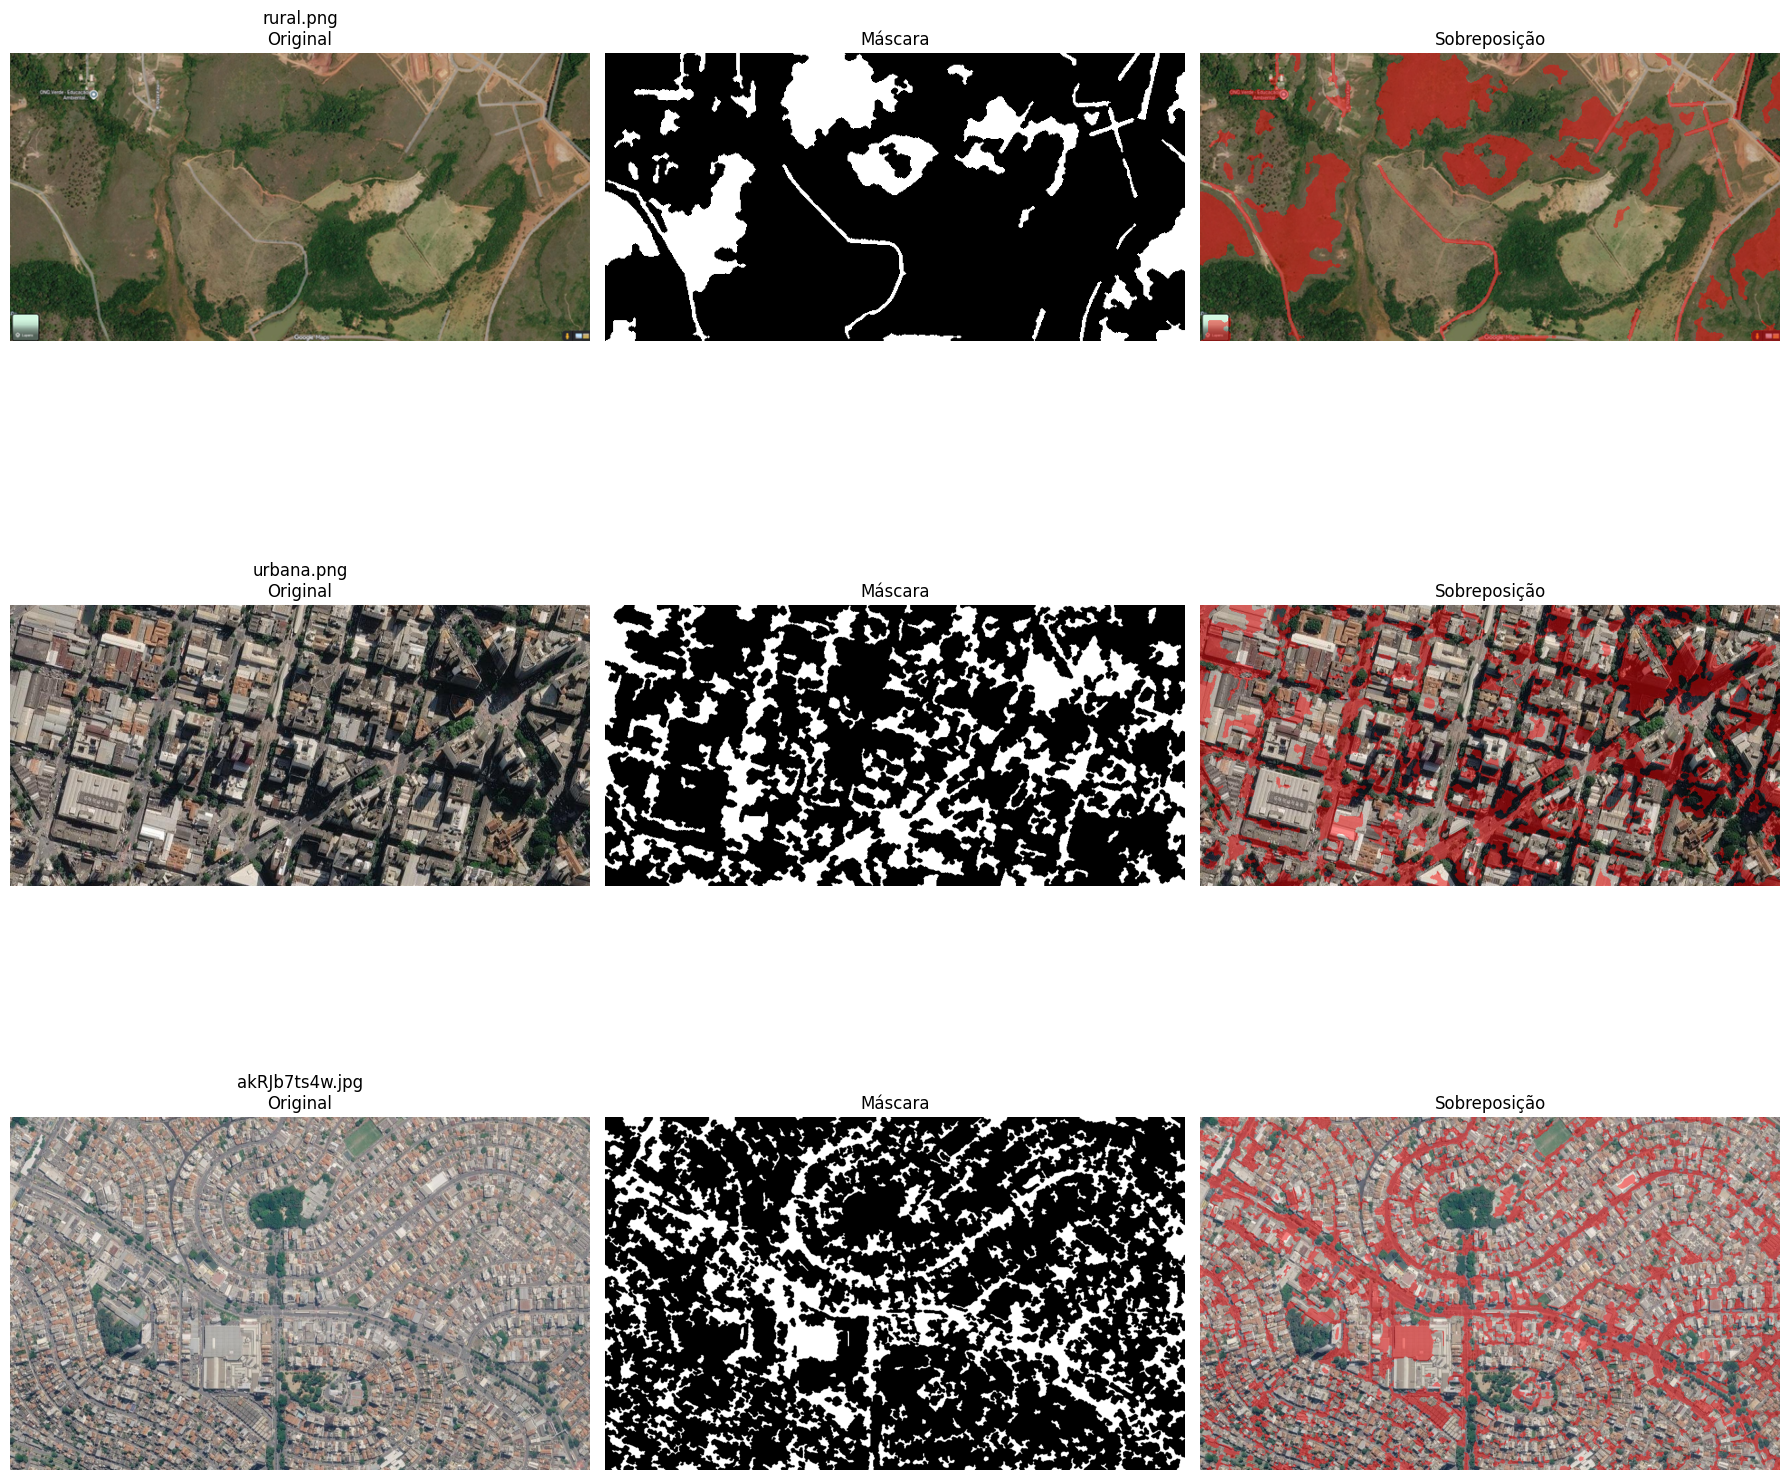

In [ ]:
from pathlib import Path
import cv2
import numpy as np
import matplotlib.pyplot as plt

from skimage.filters import frangi
from skimage.morphology import remove_small_objects, remove_small_holes
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler


PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebook":
    PROJECT_ROOT = PROJECT_ROOT.parent

RAW_DIR     = PROJECT_ROOT / "data" / "raw"
RESULTS_DIR = PROJECT_ROOT / "data" / "results"
GRAPHS_DIR  = PROJECT_ROOT / "data" / "graphs"

RAW_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
GRAPHS_DIR.mkdir(parents=True, exist_ok=True)

print(f"Raiz: {PROJECT_ROOT}")


def read_image(path):
    img = cv2.imread(str(path), cv2.IMREAD_COLOR)
    if img is None:
        raise ValueError(f"Não foi possível abrir: {path}")
    return cv2.cvtColor(img, cv2.COLOR_BGR2RGB)


def resize_max(img, max_side=1600):
    h, w = img.shape[:2]
    s = max(h, w)
    if s <= max_side:
        return img, 1.0

    scale = max_side / s
    new_w = int(w * scale)
    new_h = int(h * scale)
    out = cv2.resize(img, (new_w, new_h), interpolation=cv2.INTER_AREA)
    return out, scale


def local_std(gray, k=15):
    gray = gray.astype(np.float32) / 255.0
    mean = cv2.blur(gray, (k, k))
    mean2 = cv2.blur(gray * gray, (k, k))
    std = np.sqrt(np.maximum(mean2 - mean * mean, 0))
    return std


def build_features(img_rgb):
    img = img_rgb.astype(np.uint8)

    lab = cv2.cvtColor(img, cv2.COLOR_RGB2LAB)
    hsv = cv2.cvtColor(img, cv2.COLOR_RGB2HSV)
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

    l, a, b = cv2.split(lab)
    h, s, v = cv2.split(hsv)

    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    gray_eq = clahe.apply(gray)

    fr = frangi(
        gray_eq.astype(float) / 255.0,
        sigmas=range(1, 5),
        black_ridges=False
    )

    fr_inv = frangi(
        1.0 - gray_eq.astype(float) / 255.0,
        sigmas=range(1, 5),
        black_ridges=False
    )

    line = np.maximum(fr, fr_inv)
    std = local_std(gray_eq, k=17)

    edges = cv2.Canny(gray_eq, 60, 160)
    edges = edges.astype(np.float32) / 255.0

    ndvi_like = (img[:, :, 1].astype(float) - img[:, :, 0].astype(float)) / (
        img[:, :, 1].astype(float) + img[:, :, 0].astype(float) + 1e-6
    )

    feats = np.dstack([
        l / 255.0,
        a / 255.0,
        b / 255.0,
        h / 179.0,
        s / 255.0,
        v / 255.0,
        gray_eq / 255.0,
        line,
        std,
        edges,
        ndvi_like
    ])

    return feats, line, std, ndvi_like


def normalize01(x):
    x = x.astype(np.float32)
    return (x - x.min()) / (x.max() - x.min() + 1e-6)


def oriented_line_opening(mask, lengths=(17, 25, 35), angles=(0, 30, 60, 90, 120, 150)):
    out = np.zeros_like(mask, dtype=np.uint8)

    for L in lengths:
        base = np.zeros((L, L), dtype=np.uint8)
        cv2.line(base, (L // 2, 2), (L // 2, L - 3), 1, 3)

        for ang in angles:
            M = cv2.getRotationMatrix2D((L // 2, L // 2), ang, 1.0)
            kernel = cv2.warpAffine(base, M, (L, L))
            kernel = (kernel > 0).astype(np.uint8)

            opened = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)
            out = np.maximum(out, opened)

    return out


def segment_roads(
    img_rgb,
    max_side=1800,
    min_area=80,
    hole_area=250,
    urban_sensitivity=0.72,
    rural_sensitivity=0.82
):
    img_small, scale = resize_max(img_rgb, max_side=max_side)
    img = cv2.bilateralFilter(img_small, d=7, sigmaColor=35, sigmaSpace=35)

    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    hsv = cv2.cvtColor(img, cv2.COLOR_RGB2HSV)
    lab = cv2.cvtColor(img, cv2.COLOR_RGB2LAB)

    h, s, v = cv2.split(hsv)
    l, a, b = cv2.split(lab)

    gray_f = gray.astype(np.float32) / 255.0
    s_f = s.astype(np.float32) / 255.0

    r = img[:, :, 0].astype(np.float32)
    g = img[:, :, 1].astype(np.float32)
    bb = img[:, :, 2].astype(np.float32)

    grayness = 1.0 - normalize01(
        np.abs(r - g) + np.abs(r - bb) + np.abs(g - bb)
    )

    ndvi_like = (g - r) / (g + r + 1e-6)
    non_veg = ndvi_like < 0.22

    clahe = cv2.createCLAHE(clipLimit=2.5, tileGridSize=(8, 8))
    gray_eq = clahe.apply(gray)

    tex = local_std(gray_eq, k=15)
    homogeneity = normalize01(1.0 - tex)

    fr_dark = frangi(
        gray_eq.astype(float) / 255.0,
        sigmas=range(1, 6),
        black_ridges=True
    )

    fr_light = frangi(
        gray_eq.astype(float) / 255.0,
        sigmas=range(1, 6),
        black_ridges=False
    )

    linearity = normalize01(np.maximum(fr_dark, fr_light))

    urban_score = (
        0.38 * grayness +
        0.25 * (1.0 - s_f) +
        0.20 * homogeneity +
        0.17 * linearity
    )

    urban_score = normalize01(urban_score)

    rural_score = (
        0.65 * linearity +
        0.20 * homogeneity +
        0.15 * (1.0 - s_f)
    )

    rural_score = normalize01(rural_score)

    urban_mask = urban_score > np.quantile(urban_score, urban_sensitivity)
    rural_mask = rural_score > np.quantile(rural_score, rural_sensitivity)

    urban_mask = urban_mask & non_veg & (s_f < 0.62)
    rural_mask = rural_mask & non_veg

    rural_mask = oriented_line_opening(
        rural_mask.astype(np.uint8),
        lengths=(9, 15, 23, 31),
        angles=(0, 15, 30, 45, 60, 75, 90, 105, 120, 135, 150, 165)
    ).astype(bool)

    urban_mask = oriented_line_opening(
        urban_mask.astype(np.uint8),
        lengths=(15, 25, 35),
        angles=(0, 20, 40, 60, 80, 100, 120, 140, 160)
    ).astype(bool) | urban_mask

    mask = urban_mask | rural_mask

    close_kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (7, 7))
    dilate_kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3))

    mask = cv2.dilate(mask.astype(np.uint8), dilate_kernel, iterations=1)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, close_kernel)

    mask = mask.astype(bool)
    mask = remove_small_objects(mask, min_size=min_area)
    mask = remove_small_holes(mask, area_threshold=hole_area)

    if scale != 1.0:
        mask = cv2.resize(
            mask.astype(np.uint8),
            (img_rgb.shape[1], img_rgb.shape[0]),
            interpolation=cv2.INTER_NEAREST
        ).astype(bool)

    return mask


def make_overlay(img_rgb, mask, alpha=0.45):
    overlay = img_rgb.copy().astype(np.float32)
    color = np.zeros_like(overlay)
    color[:, :, 0] = 255

    overlay[mask] = (1 - alpha) * overlay[mask] + alpha * color[mask]
    return np.clip(overlay, 0, 255).astype(np.uint8)


def plot_road_result(img_rgb, mask, title="Resultado"):
    overlay = make_overlay(img_rgb, mask)

    fig, ax = plt.subplots(1, 3, figsize=(18, 6))

    ax[0].imshow(img_rgb)
    ax[0].set_title("Imagem original")
    ax[0].axis("off")

    ax[1].imshow(mask, cmap="gray")
    ax[1].set_title("Máscara de vias")
    ax[1].axis("off")

    ax[2].imshow(overlay)
    ax[2].set_title("Sobreposição")
    ax[2].axis("off")

    plt.suptitle(title)
    plt.tight_layout()
    plt.show()


def process_image(path, max_side=1800):
    path = Path(path)

    img = read_image(path)

    mask = segment_roads(
        img,
        max_side=max_side,
        min_area=80,
        hole_area=250,
        urban_sensitivity=0.86,
        rural_sensitivity=0.92
    )

    overlay = make_overlay(img, mask)

    mask_path = RESULTS_DIR / f"{path.stem}_mask.png"
    overlay_path = RESULTS_DIR / f"{path.stem}_overlay.png"

    cv2.imwrite(
        str(mask_path),
        (mask.astype(np.uint8) * 255)
    )

    cv2.imwrite(
        str(overlay_path),
        cv2.cvtColor(overlay, cv2.COLOR_RGB2BGR)
    )

    return {
        "name": path.name,
        "image": img,
        "mask": mask,
        "overlay": overlay,
        "mask_path": mask_path,
        "overlay_path": overlay_path
    }

def plot_all_results(results):

    n = len(results)

    fig, axes = plt.subplots(
        nrows=n,
        ncols=3,
        figsize=(18, 6*n)
    )

    if n == 1:
        axes = np.array([axes])

    for i, r in enumerate(results):

        axes[i,0].imshow(r["image"])
        axes[i,0].set_title(
            f'{r["name"]}\nOriginal'
        )
        axes[i,0].axis("off")

        axes[i,1].imshow(
            r["mask"],
            cmap="gray"
        )
        axes[i,1].set_title("Máscara")
        axes[i,1].axis("off")

        axes[i,2].imshow(r["overlay"])
        axes[i,2].set_title("Sobreposição")
        axes[i,2].axis("off")

    plt.tight_layout()
    plt.show()


def process_dataset(raw_dir=RAW_DIR, max_side=1600):
    exts = ["*.png", "*.jpg", "*.jpeg", "*.tif", "*.tiff", "*.bmp"]
    files = []

    for e in exts:
        files.extend(Path(raw_dir).glob(e))

    if len(files) == 0:
        raise FileNotFoundError(f"Nenhuma imagem encontrada em {raw_dir}")

    results = []

    for f in files:
        print(f"Processando: {f.name}")
        results.append(process_image(f, max_side=max_side))

    return results


results = process_dataset(
    RAW_DIR,
    max_side=1800
)

plot_all_results(results)